In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plot_bib as bc
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

########################################################
# DO WPISANIA PREZ UŻYTKOWNIKA
batt_names = {1: 'DCAAA_Alkaline_0101', 
              2: 'PSAAA_ZnC_0100',
              3: 'PScoin_Li_0100',
              4: 'LiitoKala_Lion_0102',
              5: 'RCR123A_LiFePO4_0101',
              6: 'innCraft_Lipo_0100',
              7: 'GCAA_NiMH_0100',
              8: 'Kinetic_NiCd_0100',
              9: 'aimjin_LTO_0100'}
batt_No = 6
# Method_of_measurement = '01'
# No_of_measurement = '00'
#filename = 'data/data_2025-10-15.dat'
sep = ','
markersize = 2
directory_name = 'data-valid'
########################################################

batt_dates =[ 1959, 1866, 1972, 1991, 1997, 1999, 1989, 1899, 2008 ]

def filename(batt_names, batt_No):
    return directory_name + '/' + batt_names[batt_No] + '.dat'


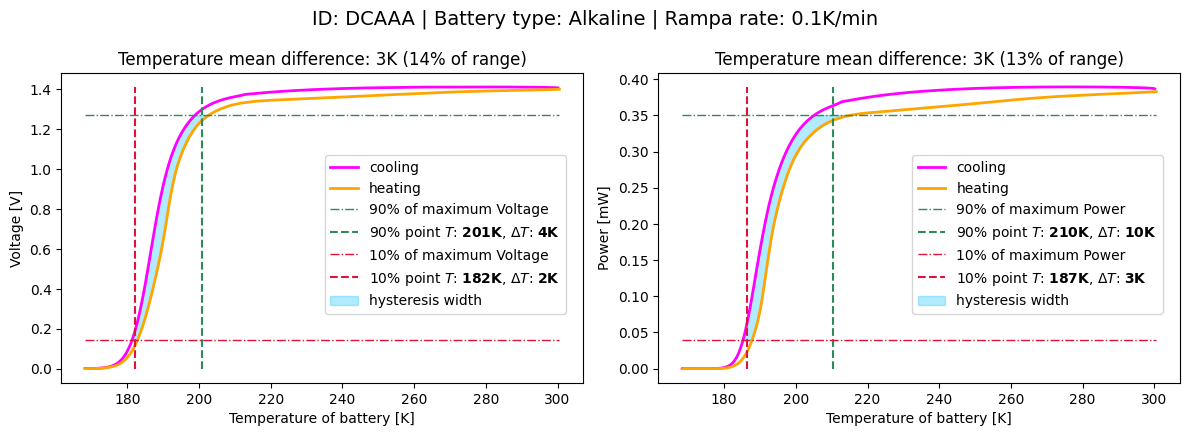

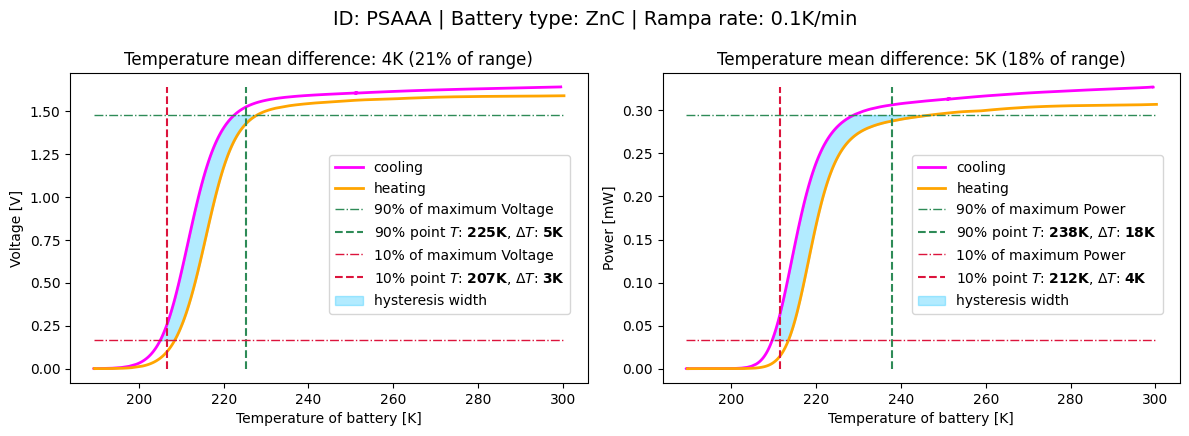

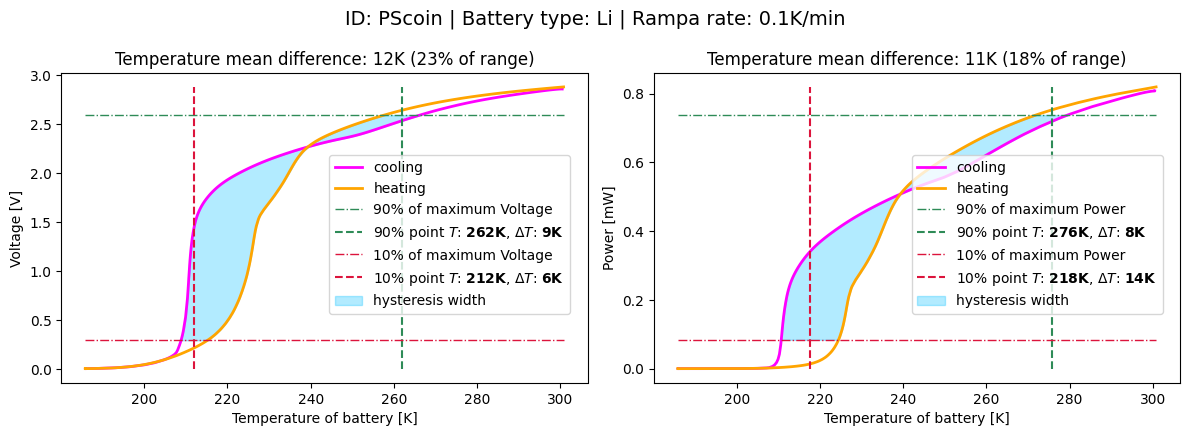

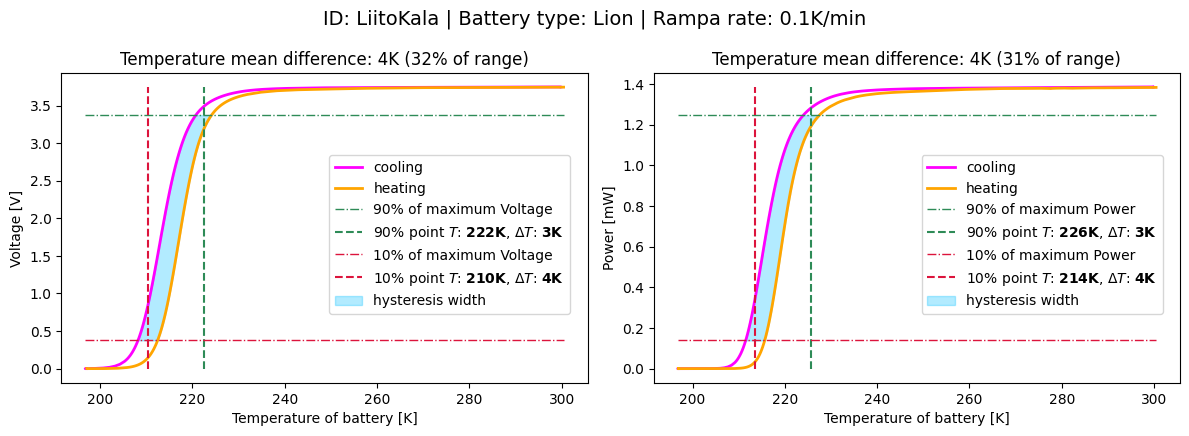

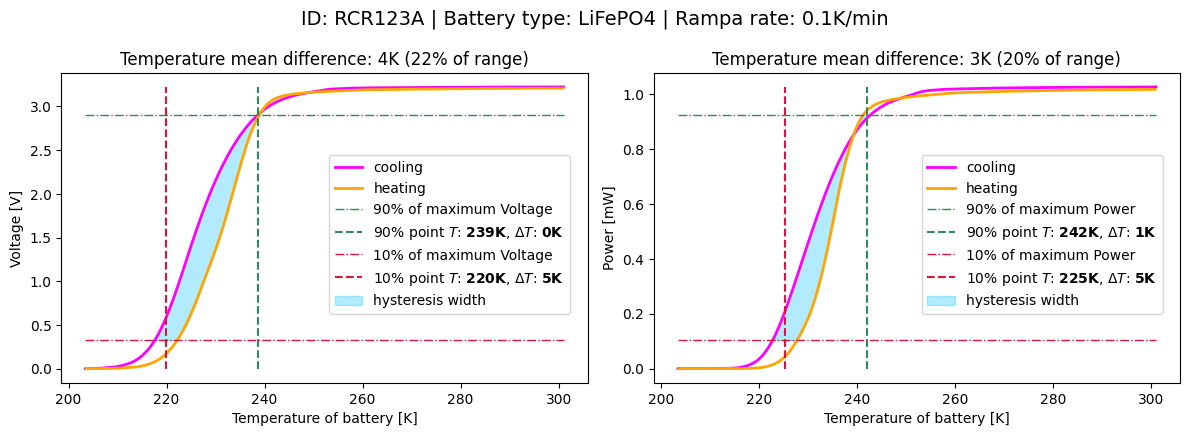

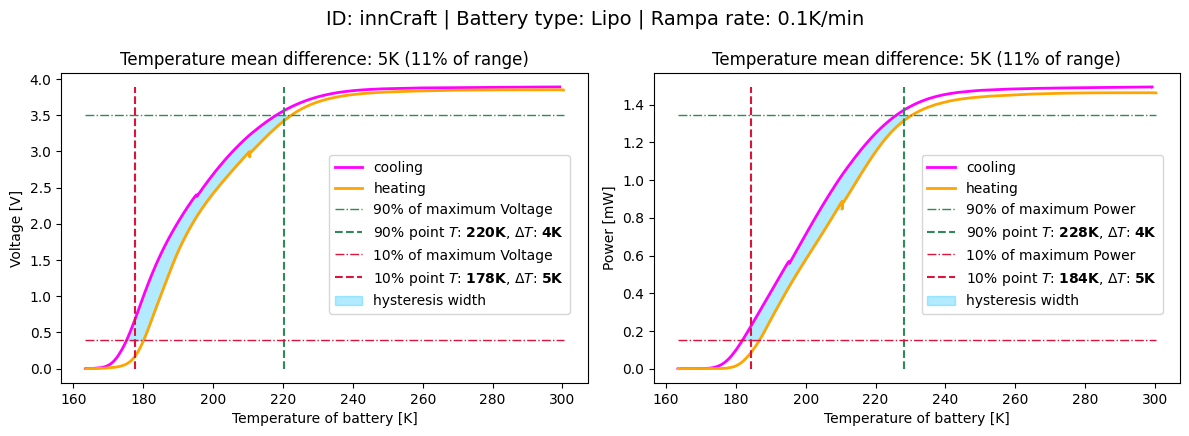

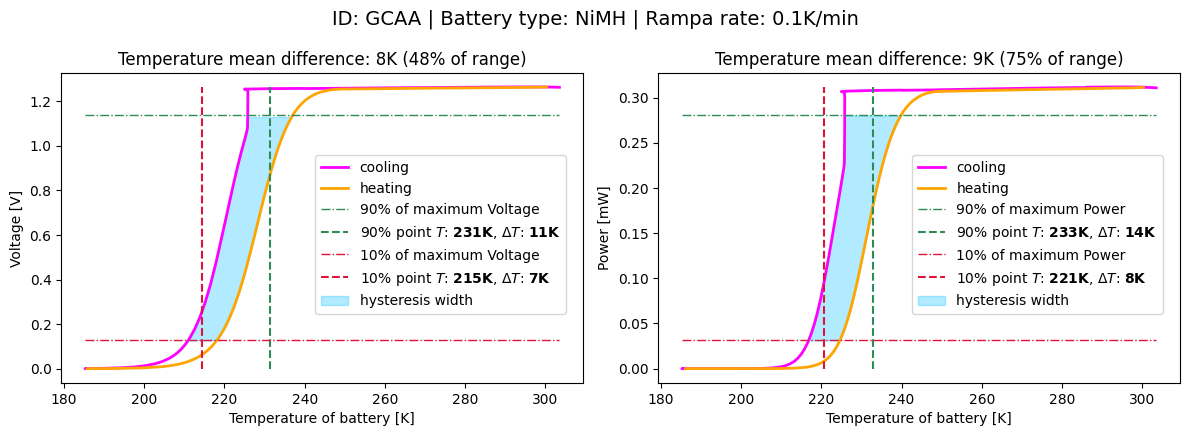

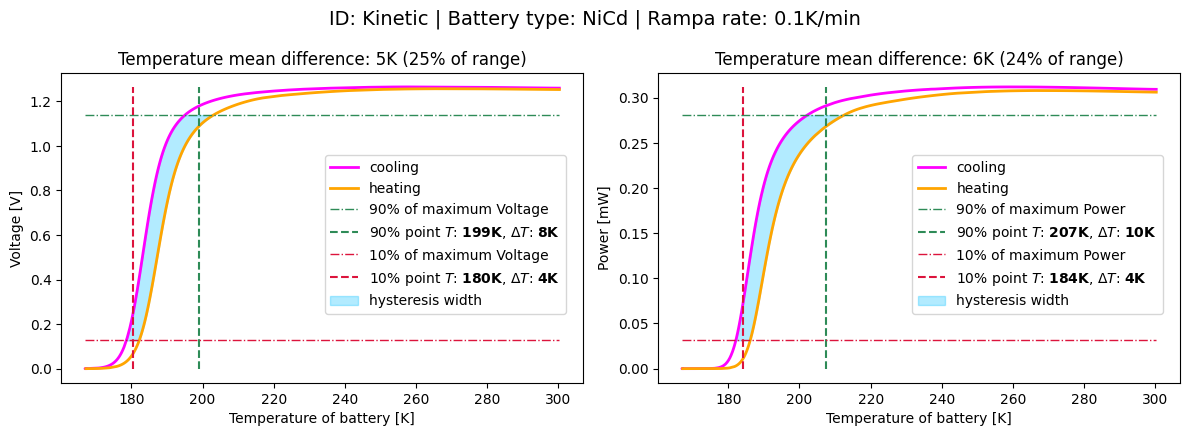

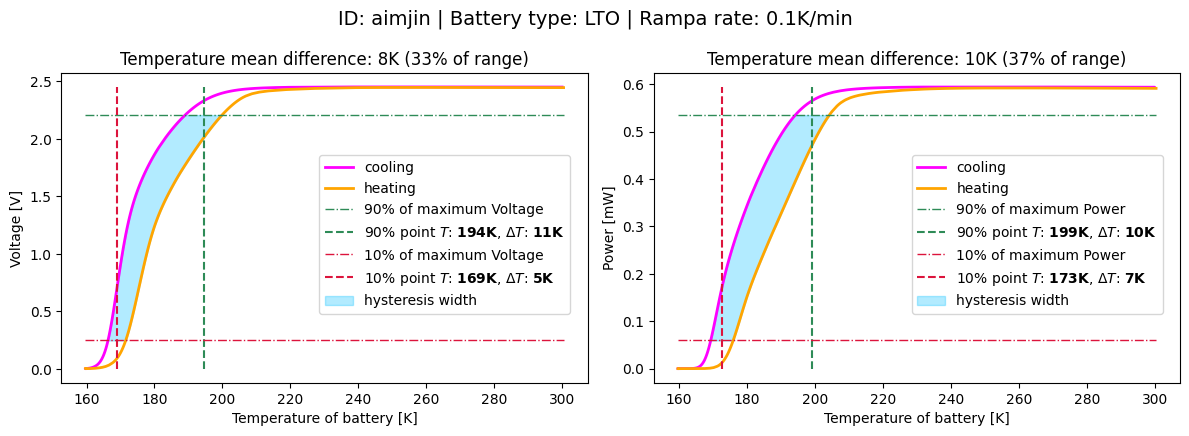

In [2]:
show_times = False

temperatures, temperaturesU, temperaturesP = [], [], []
for i in batt_names:
    try:
        data = bc.meas_data(filename= filename(batt_names= batt_names, batt_No= i), show_time= show_times)
        data.cut_garbage()
        fig, axs = plt.subplots(1, 2, figsize = (12, 4.4))
        fig.suptitle(data.info, fontsize = 14)
        data.histereza_T_VorIorP(ax= axs[0], VorIorP= 'Voltage', show_times= show_times)
        data.histereza_T_VorIorP(ax= axs[1], VorIorP= 'Power', show_times= show_times)
        plt.tight_layout()
        plt.show()
        temperatures.append([data.ID, data.batt_type, data.T10U, data.T90U, data.Voltage_diff, 
                                                        data.T10P, data.T90P, data.Power_diff])
        temperaturesU.append([data.ID, data.T90U, data.DeltaT90U, data.T10U, data.DeltaT10U, 
                                      data.Voltage_diff, data.Voltage_perc_diff])
        temperaturesP.append([data.ID, data.T90P, data.DeltaT90P, data.T10P, data.DeltaT10P,
                                      data.Power_diff, data.Power_perc_diff])
    except: pass

In [3]:
#temperatures = sorted(temperatures, key= lambda x: x[-3])

for i, vali in enumerate(temperatures):
    highlight = 5
    output = '    '
    for j, valj in enumerate(vali):
        if j == highlight: output += '\\textbf{'
        try: output += f'{valj:.0f}'
        except: output += str(valj)
        if j == highlight: output += '}'
        if j < len(vali) - 1: output += ' & '
    output += ' \\\\'
    print(output)
    print('        \\hline')

    DCAAA & Alkaline & 182 & 201 & 3 & \textbf{187} & 210 & 3 \\
        \hline
    PSAAA & ZnC & 207 & 225 & 4 & \textbf{212} & 238 & 5 \\
        \hline
    PScoin & Li & 212 & 262 & 12 & \textbf{218} & 276 & 11 \\
        \hline
    LiitoKala & Lion & 210 & 222 & 4 & \textbf{214} & 226 & 4 \\
        \hline
    RCR123A & LiFePO4 & 220 & 239 & 4 & \textbf{225} & 242 & 3 \\
        \hline
    innCraft & Lipo & 178 & 220 & 5 & \textbf{184} & 228 & 5 \\
        \hline
    GCAA & NiMH & 215 & 231 & 8 & \textbf{221} & 233 & 9 \\
        \hline
    Kinetic & NiCd & 180 & 199 & 5 & \textbf{184} & 207 & 6 \\
        \hline
    aimjin & LTO & 169 & 194 & 8 & \textbf{173} & 199 & 10 \\
        \hline


In [4]:
for i, vali in enumerate(temperaturesU):
    output = '    '
    for j, valj in enumerate(vali):
        try: output += f'{valj:.0f}'
        except: output += str(valj)
        if j < len(vali) - 1: output += ' & '
    output += ' \\\\'
    print(output)
    print('        \\hline')
    if i == 2 : print('        \\hline')

    DCAAA & 201 & 4 & 182 & 2 & 3 & 14 \\
        \hline
    PSAAA & 225 & 5 & 207 & 3 & 4 & 21 \\
        \hline
    PScoin & 262 & 9 & 212 & 6 & 12 & 23 \\
        \hline
        \hline
    LiitoKala & 222 & 3 & 210 & 4 & 4 & 32 \\
        \hline
    RCR123A & 239 & 0 & 220 & 5 & 4 & 22 \\
        \hline
    innCraft & 220 & 4 & 178 & 5 & 5 & 11 \\
        \hline
    GCAA & 231 & 11 & 215 & 7 & 8 & 48 \\
        \hline
    Kinetic & 199 & 8 & 180 & 4 & 5 & 25 \\
        \hline
    aimjin & 194 & 11 & 169 & 5 & 8 & 33 \\
        \hline


In [5]:
for i, vali in enumerate(temperaturesP):
    output = '    '
    for j, valj in enumerate(vali):
        try: output += f'{valj:.0f}'
        except: output += str(valj)
        if j < len(vali) - 1: output += ' & '
    output += ' \\\\'
    print(output)
    print('        \\hline')
    if i == 2 : print('        \\hline')

    DCAAA & 210 & 10 & 187 & 3 & 3 & 13 \\
        \hline
    PSAAA & 238 & 18 & 212 & 4 & 5 & 18 \\
        \hline
    PScoin & 276 & 8 & 218 & 14 & 11 & 18 \\
        \hline
        \hline
    LiitoKala & 226 & 3 & 214 & 4 & 4 & 31 \\
        \hline
    RCR123A & 242 & 1 & 225 & 5 & 3 & 20 \\
        \hline
    innCraft & 228 & 4 & 184 & 5 & 5 & 11 \\
        \hline
    GCAA & 233 & 14 & 221 & 8 & 9 & 75 \\
        \hline
    Kinetic & 207 & 10 & 184 & 4 & 6 & 24 \\
        \hline
    aimjin & 199 & 10 & 173 & 7 & 10 & 37 \\
        \hline


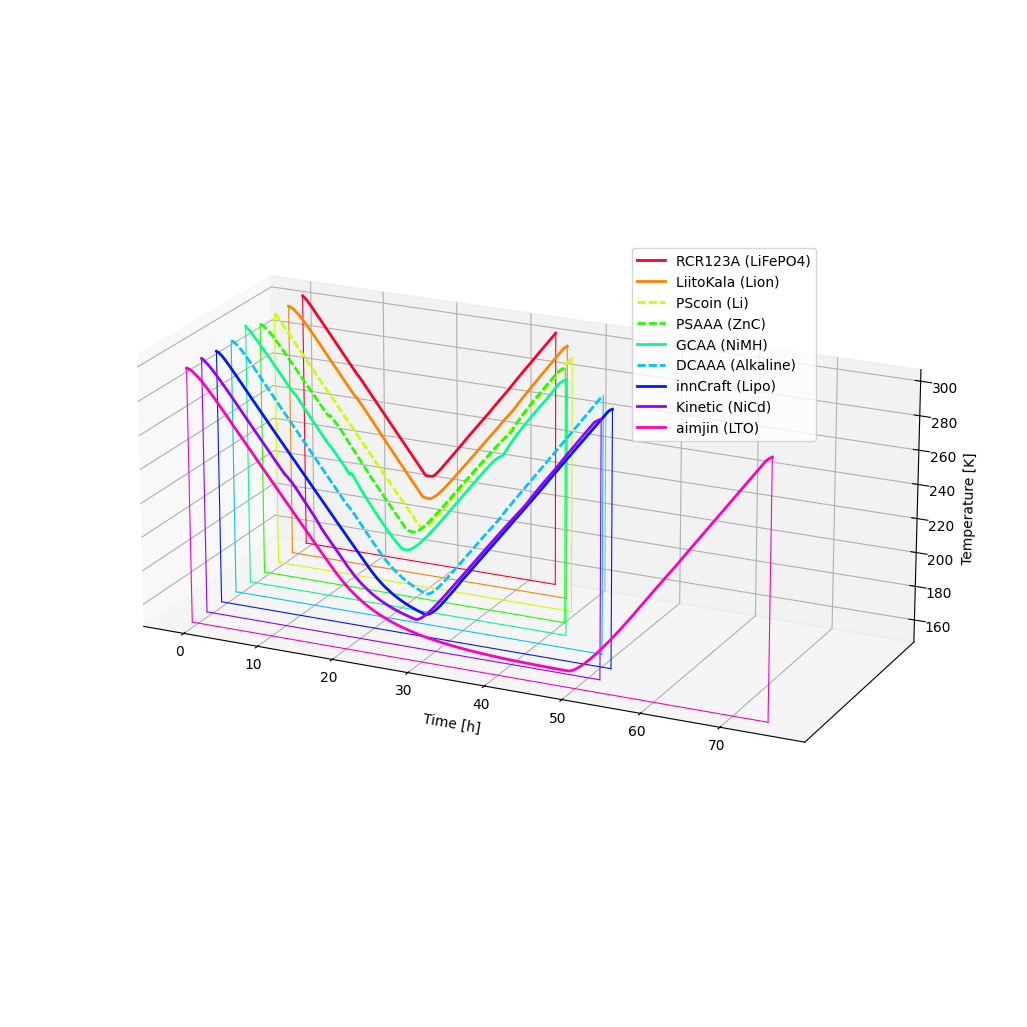

In [6]:
fig = plt.figure(figsize=(13, 18))
ax = fig.add_subplot(111, projection= '3d')

batt_names_time_sorted = sorted(batt_names, 
                                key= lambda x: bc.meas_data(filename= filename(batt_names, x)).Measurement_Time_Hours.max())
maxtime_index = batt_names_time_sorted[-1]
maxtime = bc.meas_data(filename= filename(batt_names, maxtime_index)).Measurement_Time_Hours.max()

zs = np.linspace(1, l:= len(batt_names_time_sorted) + 1, l + 1)
zs = zs.max() - zs

cmap = plt.get_cmap("gist_rainbow")
for i, vali in enumerate(batt_names_time_sorted):
    try:
        if vali <= 3: ls = (0, (3, 1))
        else: ls = '-'
        data = bc.meas_data(filename= filename(batt_names, batt_No= vali))
        
        color = cmap(i / (len(batt_names) - 1))
        data.plot_T_t_3D(fig, ax, lis= ls, z= zs[i], color= color)
    except: pass
ax.view_init(elev=20, azim=-65)
ax.set_box_aspect((2.5, 1, 1), zoom=0.8)
ax.set_yticks([])
ax.legend(loc='upper left', bbox_to_anchor=(.61, .77))


plt.show()

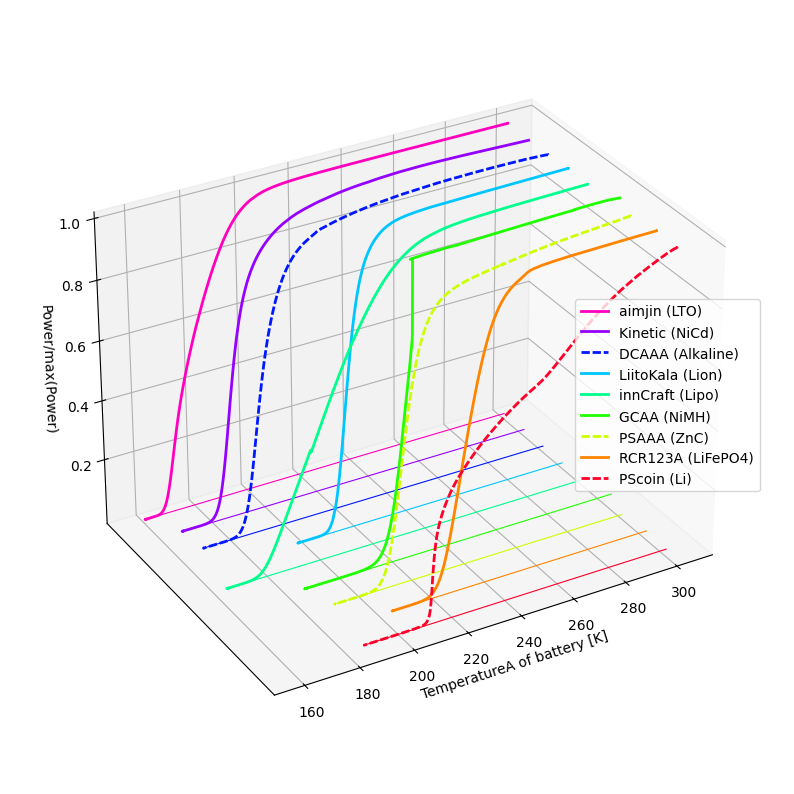

In [7]:
fig = plt.figure(figsize=(10, 16))
ax = fig.add_subplot(111, projection= '3d')

batt_names_temp_sorted = sorted(batt_names, key= lambda x: bc.meas_data(filename= filename(batt_names, x)).T90P)
mintemp_index = batt_names_temp_sorted[-1]
mintemp = bc.meas_data(filename= filename(batt_names, mintemp_index)).T90P 

zs = np.linspace(1, l:= len(batt_names_temp_sorted) + 1, l + 1)
zs = zs.max() - zs

cmap = plt.get_cmap("gist_rainbow")
for i, vali in enumerate(batt_names_temp_sorted):
    try:
        if vali <= 3: ls = (0, (3, 1))
        else: ls = '-'
        data = bc.meas_data(filename= filename(batt_names, batt_No= vali))
        
        color = cmap(1 - i / (len(batt_names) - 1))
        data.half_curve_3D(fig, ax, lis= ls, VorIorP='Power', z= zs[i], color= color, half = 1)
    except: pass
ax.view_init(elev=30, azim=-120)
ax.set_yticks([])
ax.legend(loc='upper left', bbox_to_anchor=(.72, .635))

ax.set_box_aspect((1.4, 1, 1), zoom=0.9)

plt.show()

(190.0, 270.0)

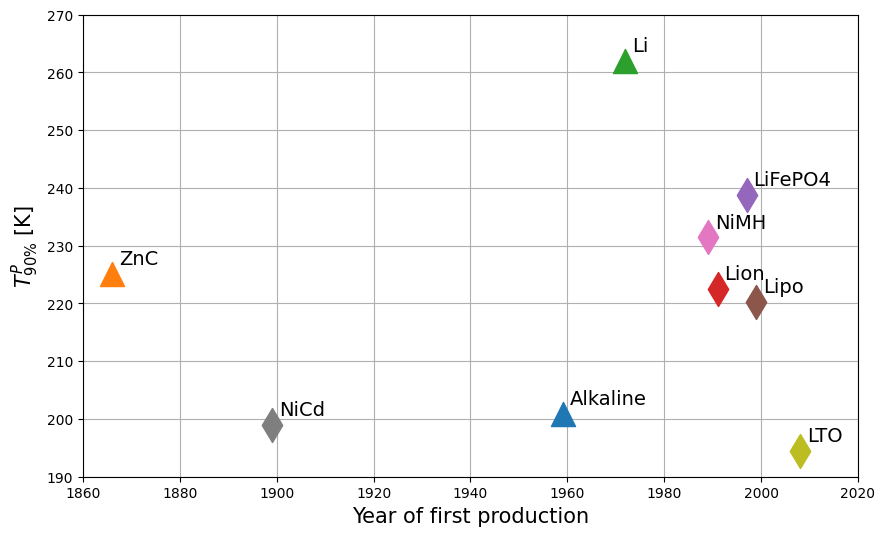

In [8]:
fig, ax = plt.subplots(1, 1, figsize = (2*5, 6))
for i, vali in enumerate(batt_names):
    if vali <= 3: marker = '^'
    else: marker = 'd'
    data = bc.meas_data(filename= filename(batt_names, batt_No= vali))
    data.T90vsDate(fig, ax, VorIorP= 'Voltage', batt_date= batt_dates[i], marker= marker)
ax.set_xlabel(r'Year of first production', fontsize = 15)
ax.set_ylabel(r'$T_{90\%}^P$ [K]', fontsize = 15)
ax.grid(zorder=1 )
ax.set_xlim(1860, 2020)
ax.set_ylim(190, 270)

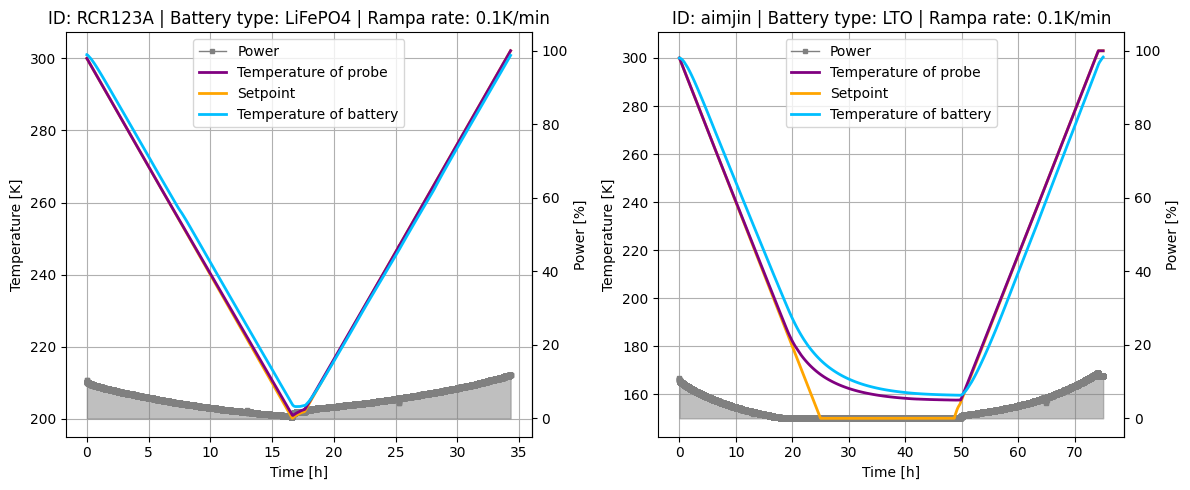

In [9]:
data1 = bc.meas_data(filename= filename(batt_names= batt_names, batt_No= 5))
data2 = bc.meas_data(filename= filename(batt_names= batt_names, batt_No= 9))
data1.cut_garbage()
data2.cut_garbage()
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].grid(zorder= 1)
ax[1].grid(zorder= 1)
ax[0].set_title(data1.info, fontsize = 12)
ax[1].set_title(data2.info, fontsize = 12)
data1.plot_T_t(fig, ax[0])
data2.plot_T_t(fig, ax[1])
plt.tight_layout()
plt.show()

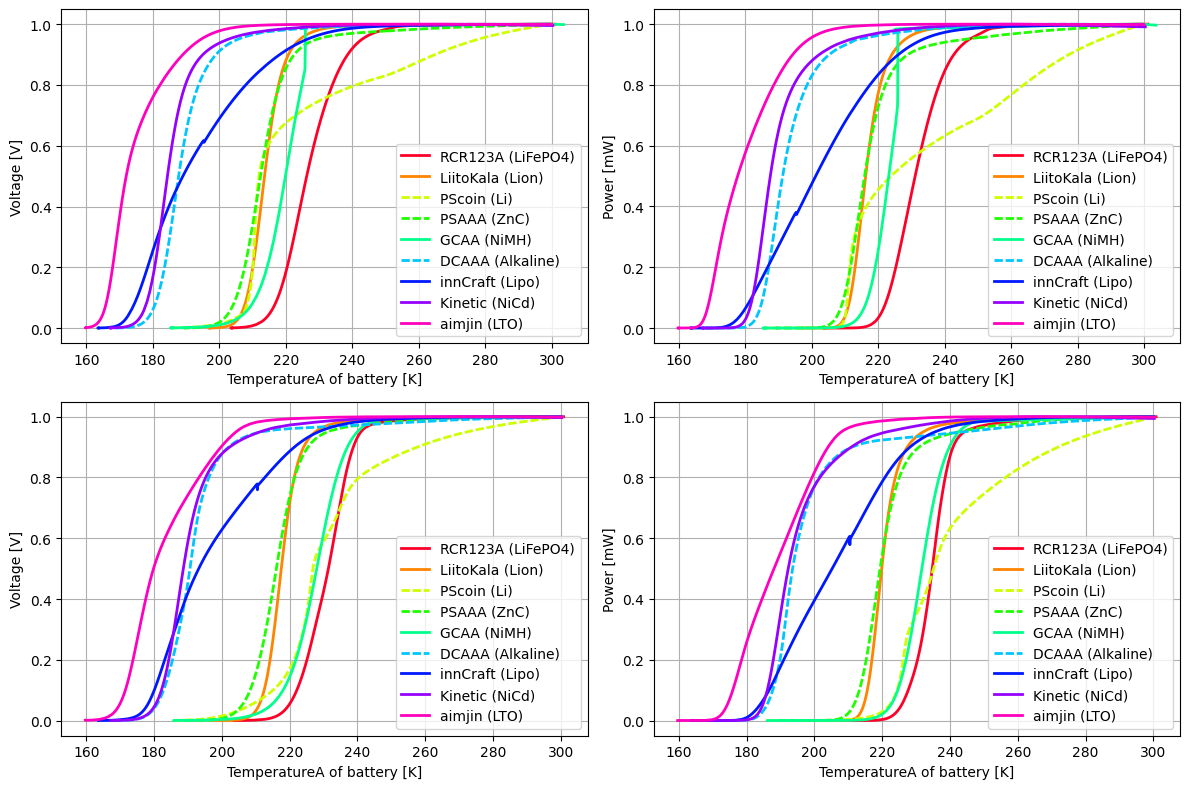

In [10]:
fig, axs = plt.subplots(2, 2, figsize = (2*6, 2*4))
cmap = plt.get_cmap('gist_rainbow')

cmap = plt.get_cmap("gist_rainbow")
for i, vali in enumerate(batt_names_time_sorted):
    try:
        if vali <= 3: ls = (0, (3, 1))
        else: ls = '-'
        data = bc.meas_data(filename= filename(batt_names= batt_names, batt_No= vali))
        color = cmap(i / (len(batt_names) - 1))
        data.half_curve(fig, ax= axs[0,0], VorIorP= 'Voltage', half= 1, lis= ls, color= color)
        data.half_curve(fig, ax= axs[1,0], VorIorP= 'Voltage', half= 2, lis= ls, color= color)
        data.half_curve(fig, ax= axs[0,1], VorIorP= 'Power', half= 1, lis= ls, color= color)
        data.half_curve(fig, ax= axs[1,1], VorIorP= 'Power', half= 2, lis= ls, color= color)
        plt.tight_layout()
    except: pass
for ax in axs.flat: ax.grid()

75.06972222222223


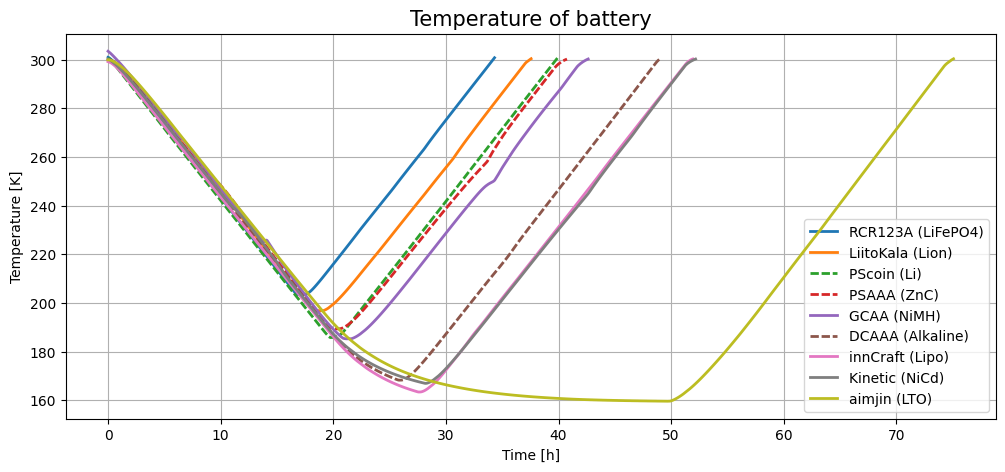

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12,5))
ax.set_title('Temperature of battery', fontsize = 15)
ax.grid(zorder= 1)
fig.subplots_adjust(hspace=0.25)

batt_names_time_sorted = sorted(batt_names, key= lambda x: bc.meas_data(filename= filename(batt_names, x)).Measurement_Time_Hours.max())
maxtime_index = batt_names_time_sorted[-1]
maxtime = bc.meas_data(filename= filename(batt_names, maxtime_index)).Measurement_Time_Hours.max()
print(maxtime)

for i in batt_names_time_sorted:
    try:
        if i <= 3: ls = (0, (3, 1))
        else: ls = '-'
        data = bc.meas_data(filename= filename(batt_names, batt_No= i))
        data.plot_T_t(fig, ax, batt= True, probe= False, setp= False, lis= ls, maxtime= False)
    except: pass